<a href="https://colab.research.google.com/github/anirbansen2709/AI-ML_Assignments/blob/main/CV_assignment1_35_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem 1**

Handwritten English Character Recognition Using Classical Vision & Machine Learning

Goal -
Develop a classical computer-vision-based recognition system for handwritten English
letters (A–Z). The system must use low-level and mid-level feature extraction and train
classical ML models on the EMNIST Letters dataset. The trained system will then evaluate
a real handwritten sample provided by the student.

 - Ensure clear, readable code and well-organized
documentation. Present the study logically,
summarizing the problem and key findings.

In [3]:
# ==============================================================================
# 1. IMAGE PROCESSING & COMPUTER VISION LIBRARIES
# ==============================================================================
import cv2  # OpenCV for core image loading, resizing, and transformations
import numpy as np  # For numerical operations and handling image matrices
from skimage.feature import local_binary_pattern, hog  # For texture (LBP) and gradient (HOG) feature extraction
from skimage import exposure  # For histogram equalization / CLAHE preprocessing
import torchvision  # For official dataset downloading and handling
from skimage.feature import hog # Extract Histogram of Oriented Gradients (HOG) for a given image.

# ==============================================================================
# 2. MACHINE LEARNING & DATA SPLITTING (scikit-learn / XGBoost)
# ==============================================================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score  # For 80-20 stratified split and 5-fold CV
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # For feature normalization (Min-Max / Z-score)
from sklearn.decomposition import PCA  # For dimensionality reduction (Optional/Required depending on problem)

# Classical ML Classifiers (Include the ones relevant to your chosen problem)
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.neighbors import KNeighborsClassifier  # k-Nearest Neighbors (Problem 1)
from sklearn.linear_model import LogisticRegression  # Logistic Regression (Problem 1)

# ==============================================================================
# 3. EVALUATION METRICS
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # For model evaluation

# ==============================================================================
# 4. DATA HANDLING & VISUALIZATION
# ==============================================================================
import pandas as pd  # For structured feature matrices / CSV storage
import matplotlib.pyplot as plt  # For plotting label distributions, bar charts, and test images
import seaborn as sns  # For clean confusion matrix heatmaps

# ==============================================================================
# 5. UTILITIES
# ==============================================================================
from google.colab import files
import io

# Part 1 – Dataset Selection & Preparation

1. Load the EMNIST Letters dataset.
2. Optionally sample 10k–20k images.
3. Normalize images to 28×28 grayscale.
4. Ensure labels correspond to characters A–Z.
5. Collect one real handwritten test image (scanned or photographed).

In [4]:
# @title Load the EMNIST Letters dataset
# Torchvision automatically fetches the official binaries to circumvent zip errors.
emnist_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',
    download=True
)

# Extract dataset tensors directly into native NumPy array format
X_raw = emnist_dataset.data.numpy()
y_raw = emnist_dataset.targets.numpy()

100%|██████████| 562M/562M [00:04<00:00, 121MB/s]


In [5]:
# @title Sample 10k–20k images.
sample_size = 20000
np.random.seed(42)  # Seeds generation for consistency across notebook runs
indices = np.random.choice(len(X_raw), sample_size, replace=False)
X_data = X_raw[indices]
y_data = y_raw[indices]

## Ensure labels correspond to characters A–Z.

#### Summary Statitstics

In [6]:
# 1. Print Total Subsampled Dataset Size
print(f"Total Subsampled Dataset Size: {X_data.shape[0]} images")
print(f"Image Canvas Dimensions      : {X_data.shape[1]}x{X_data.shape[2]} pixels\n")
# EMNIST 'letters' maps categories from 1 to 26 matching A through Z sequentially.
print(f"Minimum Label Index Present: {y_data.min()} (Maps to 'A')")
print(f"Maximum Label Index Present: {y_data.max()} (Maps to 'Z')")
# 2. Compute Category-wise Image Counts
# Maps class integers 1-26 to their corresponding character letters A-Z
category_counts = {chr(label + 64): np.sum(y_data == label) for label in range(1, 27)}

print("=== CATEGORY-WISE IMAGE COUNTS ===")
# Print the results cleanly in a 4-column grid layout to save vertical space
char_list = list(category_counts.items())
for i in range(0, len(char_list), 4):
    row_str = "  |  ".join([f"'{char}': {count:<4}" for char, count in char_list[i:i+4]])
    print(row_str)

Total Subsampled Dataset Size: 20000 images
Image Canvas Dimensions      : 28x28 pixels

Minimum Label Index Present: 1 (Maps to 'A')
Maximum Label Index Present: 26 (Maps to 'Z')
=== CATEGORY-WISE IMAGE COUNTS ===
'A': 823   |  'B': 733   |  'C': 790   |  'D': 744 
'E': 736   |  'F': 781   |  'G': 732   |  'H': 737 
'I': 755   |  'J': 781   |  'K': 785   |  'L': 767 
'M': 755   |  'N': 759   |  'O': 742   |  'P': 791 
'Q': 787   |  'R': 808   |  'S': 757   |  'T': 802 
'U': 782   |  'V': 781   |  'W': 774   |  'X': 748 
'Y': 765   |  'Z': 785 


Dataset Images are already in 28x28 dimensions

#### Distribution Plots

/tmp/ipykernel_15879/2767766302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_data, palette="viridis")


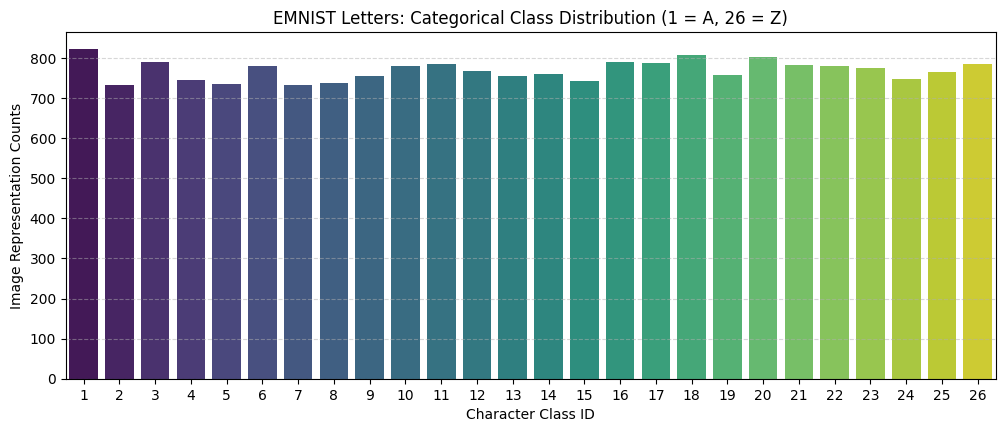

In [7]:
# Plot the statistical distribution of character classes (Rubric Requirement)
plt.figure(figsize=(12, 4.5))
sns.countplot(x=y_data, palette="viridis")
plt.title('EMNIST Letters: Categorical Class Distribution (1 = A, 26 = Z)', fontsize=12)
plt.xlabel('Character Class ID')
plt.ylabel('Image Representation Counts')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Display an image from dataset

In [8]:
# Helper Function
def display_image(image, title):
  plt.figure(figsize=(3, 3))
  plt.imshow(image, cmap='gray')
  plt.title(title)
  plt.axis('off')  # Hide grid pixels for a clean visual presentation
  plt.show()

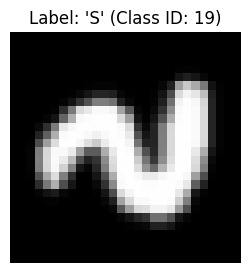

In [9]:
# 1. Select a random index from your subsampled dataset
random_idx = np.random.choice(len(X_data))
# 2. Extract the image matrix and its corresponding label index
sample_image = X_data[random_idx]
label_idx = y_data[random_idx]
# 3. Map the EMNIST 1-26 integer index back to its alphabetical character (1=A, 26=Z)
alphabetical_label = chr(label_idx + 64)
# 4. Render the image canvas using Matplotlib
title = f"Label: '{alphabetical_label}' (Class ID: {label_idx})"
display_image(sample_image, title)

#### Handwritten test image

Please upload your handwritten letter image:


Saving Screenshot 2026-05-23 at 12.24.52 PM.png to Screenshot 2026-05-23 at 12.24.52 PM.png
User uploaded file "Screenshot 2026-05-23 at 12.24.52 PM.png"
File saved as Screenshot 2026-05-23 at 12.24.52 PM.png


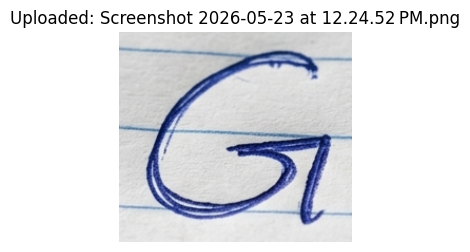

In [10]:
# Provide upload option
print("Please upload your handwritten letter image:")
uploaded = files.upload()
for file_name in uploaded.keys():
  print(f'User uploaded file "{file_name}"')
  # Save the uploaded file using its original filename
  with open(file_name, 'wb') as f:
      f.write(uploaded[file_name])
  print(f'File saved as {file_name}')

# Display the uploaded image
img = cv2.imread(file_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display_image(img_rgb, f"Uploaded: {file_name}")

#### Normalize image to 28×28 grayscale.

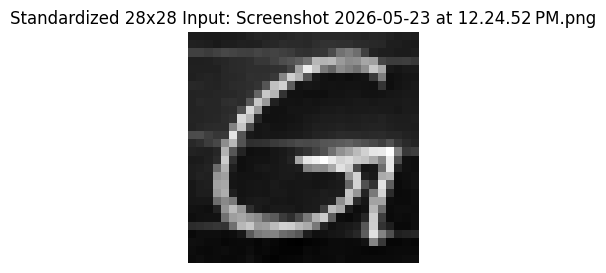

In [11]:
def standardize_to_28x28_grayscale(image_path):
    """
    Standardizes an external image to the 28x28 grayscale format used by EMNIST.
    Uses direct resizing without cropping.
    """
    # 1. Load the image
    img = cv2.imread(image_path)
    # 2. Convert to Grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    # 3. Invert Colors - EMNIST is white digits on black background. Real scans are usually black ink on white paper.
    inverted = cv2.bitwise_not(gray)
    # 4. Resize to 28x28 - Using INTER_AREA interpolation which is best for shrinking images
    resized = cv2.resize(inverted, (28, 28), interpolation=cv2.INTER_AREA)
    return resized

processed_img = standardize_to_28x28_grayscale(file_name)
display_image(processed_img, f"Standardized 28x28 Input: {file_name}")

# Part 2 – Preprocessing and Feature Extraction

In [21]:
# Perform an 80-20 stratified split for training/testing arrays
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.20, stratify=y_data, random_state=42
)
print(f"Total Master Subsampled Collection : {X_data.shape[0]} images")
print(f"Stratified Training Dataset Allocation: {X_train_raw.shape[0]} images")
print(f"Stratified Testing Dataset Allocation : {X_test_raw.shape[0]} images")

Total Master Subsampled Collection : 20000 images
Stratified Training Dataset Allocation: 16000 images
Stratified Testing Dataset Allocation : 4000 images


#### Low-Level Features

In [22]:
def apply_low_level_preprocessing(images):
    """
    Handles explicit grayscale conversion, contrast equalization, and noise smoothing.
    """
    preprocessed_images = []
    for img in images:
        # Ensure the array data type is standard uint8 for OpenCV operations
        img_uint8 = img.astype(np.uint8)
        # 1. Convert to grayscale
        # Check if the image has 3 color channels (like a photographed test image) [cite: 73]
        if len(img_uint8.shape) == 3 and img_uint8.shape[2] == 3:
            gray_img = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
        else:
            # If it's already a single-channel EMNIST matrix, keep it as is
            gray_img = img_uint8
        # 2. Apply histogram normalization/equalization [cite: 53, 78]
        eq_img = cv2.equalizeHist(gray_img)
        # 3. Apply Gaussian or median blur
        # 3x3 Gaussian kernel to suppress micro-level pixel noise [cite: 54]
        blurred_img = cv2.GaussianBlur(eq_img, (3, 3), 0)
        preprocessed_images.append(blurred_img)

    return preprocessed_images

#### Mid Level Features

In [23]:
def extract_spatial_edges(img):
    """Extracts Canny Edges and maps them to a downsampled 7x7 spatial structural grid."""
    edges = cv2.Canny(img, 100, 200)
    # Downsample the 28x28 edge canvas to a 7x7 map to form a clean 49-element layout vector
    edge_spatial = cv2.resize(edges, (7, 7), interpolation=cv2.INTER_AREA).flatten()
    return edge_spatial / 255.0

def extract_hog_vector(img):
    """Extracts Histogram of Oriented Gradients (HOG) structural descriptors."""
    features = hog(img, orientations=8, pixels_per_cell=(7, 7),
                   cells_per_block=(1, 1), visualize=False)
    return features

def extract_lbp_histogram(img):
    """Extracts Local Binary Pattern (LBP) texture descriptors as a normalized histogram."""
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")
    # FIX: Lock n_bins to a constant 10 instead of computing it dynamically via lbp.max()
    n_bins = 10
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)  # Safe division guard-rail
    return hist

def extract_orb_keypoints_count(img):
    # Compute ORB keypoints if applicable
    orb = cv2.ORB_create(nfeatures=10)
    keypoints, _ = orb.detectAndCompute(img, None)
    # Feature 5: Keypoint Count (Quantifies high-frequency corner junctions)
    keypoint_count = len(keypoints) / 10.0
    return keypoint_count

def extract_component_count(img):
    # Extract contours or connected components
    edges = cv2.Canny(img, 100, 200)
    num_labels, labels = cv2.connectedComponents(edges)
    # Feature 2: Component Count (Normalized scale of isolated structural loops)
    component_count = num_labels / 10.0
    return component_count

def extract_mid_level_features(preprocessed_images):
    """
    Extracts distinct geometric and structural features to build the feature matrix.
    """
    feature_matrix = []
    for img in preprocessed_images:
        # Feature 1 - Sobel/Canny edge detection
        edge_spatial = extract_spatial_edges(img)
        # Feature 2 - HOG Vector
        hog_vector = extract_hog_vector(img)
        # Feature 3 - LBP Feature
        lbp_feature = extract_lbp_histogram(img)
        # Feature 4 - ORB Keypoints Count
        keypoint_count = extract_orb_keypoints_count(img)
        # Feature 5 - Contour/connected components
        component_count = extract_component_count(img)
        # Consolidate handcrafted features into a single array
        feature_vector = np.concatenate([
            edge_spatial,
            hog_vector,
            lbp_feature,
            np.array([keypoint_count]),
            np.array([component_count])
        ])
        feature_matrix.append(feature_vector)
    return np.array(feature_matrix)

##### TBD - Gabor Filter

In [24]:
print("Applying Low-Level Preprocessing...")
X_train_preprocessed = apply_low_level_preprocessing(X_train_raw)
X_test_preprocessed = apply_low_level_preprocessing(X_test_raw)

print("Extracting Mid-Level Feature Matrices...")
X_train_features = extract_mid_level_features(X_train_preprocessed)
X_test_features = extract_mid_level_features(X_test_preprocessed)

Applying Low-Level Preprocessing...
Extracting Mid-Level Feature Matrices...


In [26]:
# Normalize features using Min-Max scaling to squash values between [0,1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)
print(f"Engineered Training Feature Matrix Shape: {X_train_scaled.shape}")
print(f"Engineered Testing Feature Matrix Shape : {X_test_scaled.shape}")

Engineered Training Feature Matrix Shape: (16000, 189)
Engineered Testing Feature Matrix Shape : (4000, 189)


# Part 3 – Model Training

Train the following classical ML classifiers using extracted features:

*   k-NN
*   SVM
*   Random Forest
*   Logistic Regression

Use training/validation split or k-fold CV.

In [42]:
from sklearn.svm import LinearSVC

# Initialize the 4 classical ML classifiers
models = {
    "k-NN": KNeighborsClassifier(
        n_neighbors=10,
        weights='distance'
    ),
    "Linear SVM": LinearSVC(
        max_iter=100,
        random_state=42,
        dual=False
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=100,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    )
}

# Iterate through the model repository and fit each classifier on the scaled training features
print("Training models on engineered handcrafted features...")
for name, model in models.items():
    print(f" ⏳ Training {name} Classifier...")
    # Train the model strictly using the engineered feature matrix
    model.fit(X_train_scaled, y_train)

Training models on engineered handcrafted features...
 ⏳ Training k-NN Classifier...
 ⏳ Training Linear SVM Classifier...
 ⏳ Training Random Forest Classifier...
 ⏳ Training Logistic Regression Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


TBD - use of cross-validation

# Part 4 – Model Evaluation

Compute:

*   Accuracy
*   Precision
*   Recall
*   F1-score
* Confusion Matrix
* Performance on the handwritten test letter generated by you

In [43]:
def evaluate_models(y_test, y_pred):
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
  rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
  f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
  return acc, prec, rec, f1

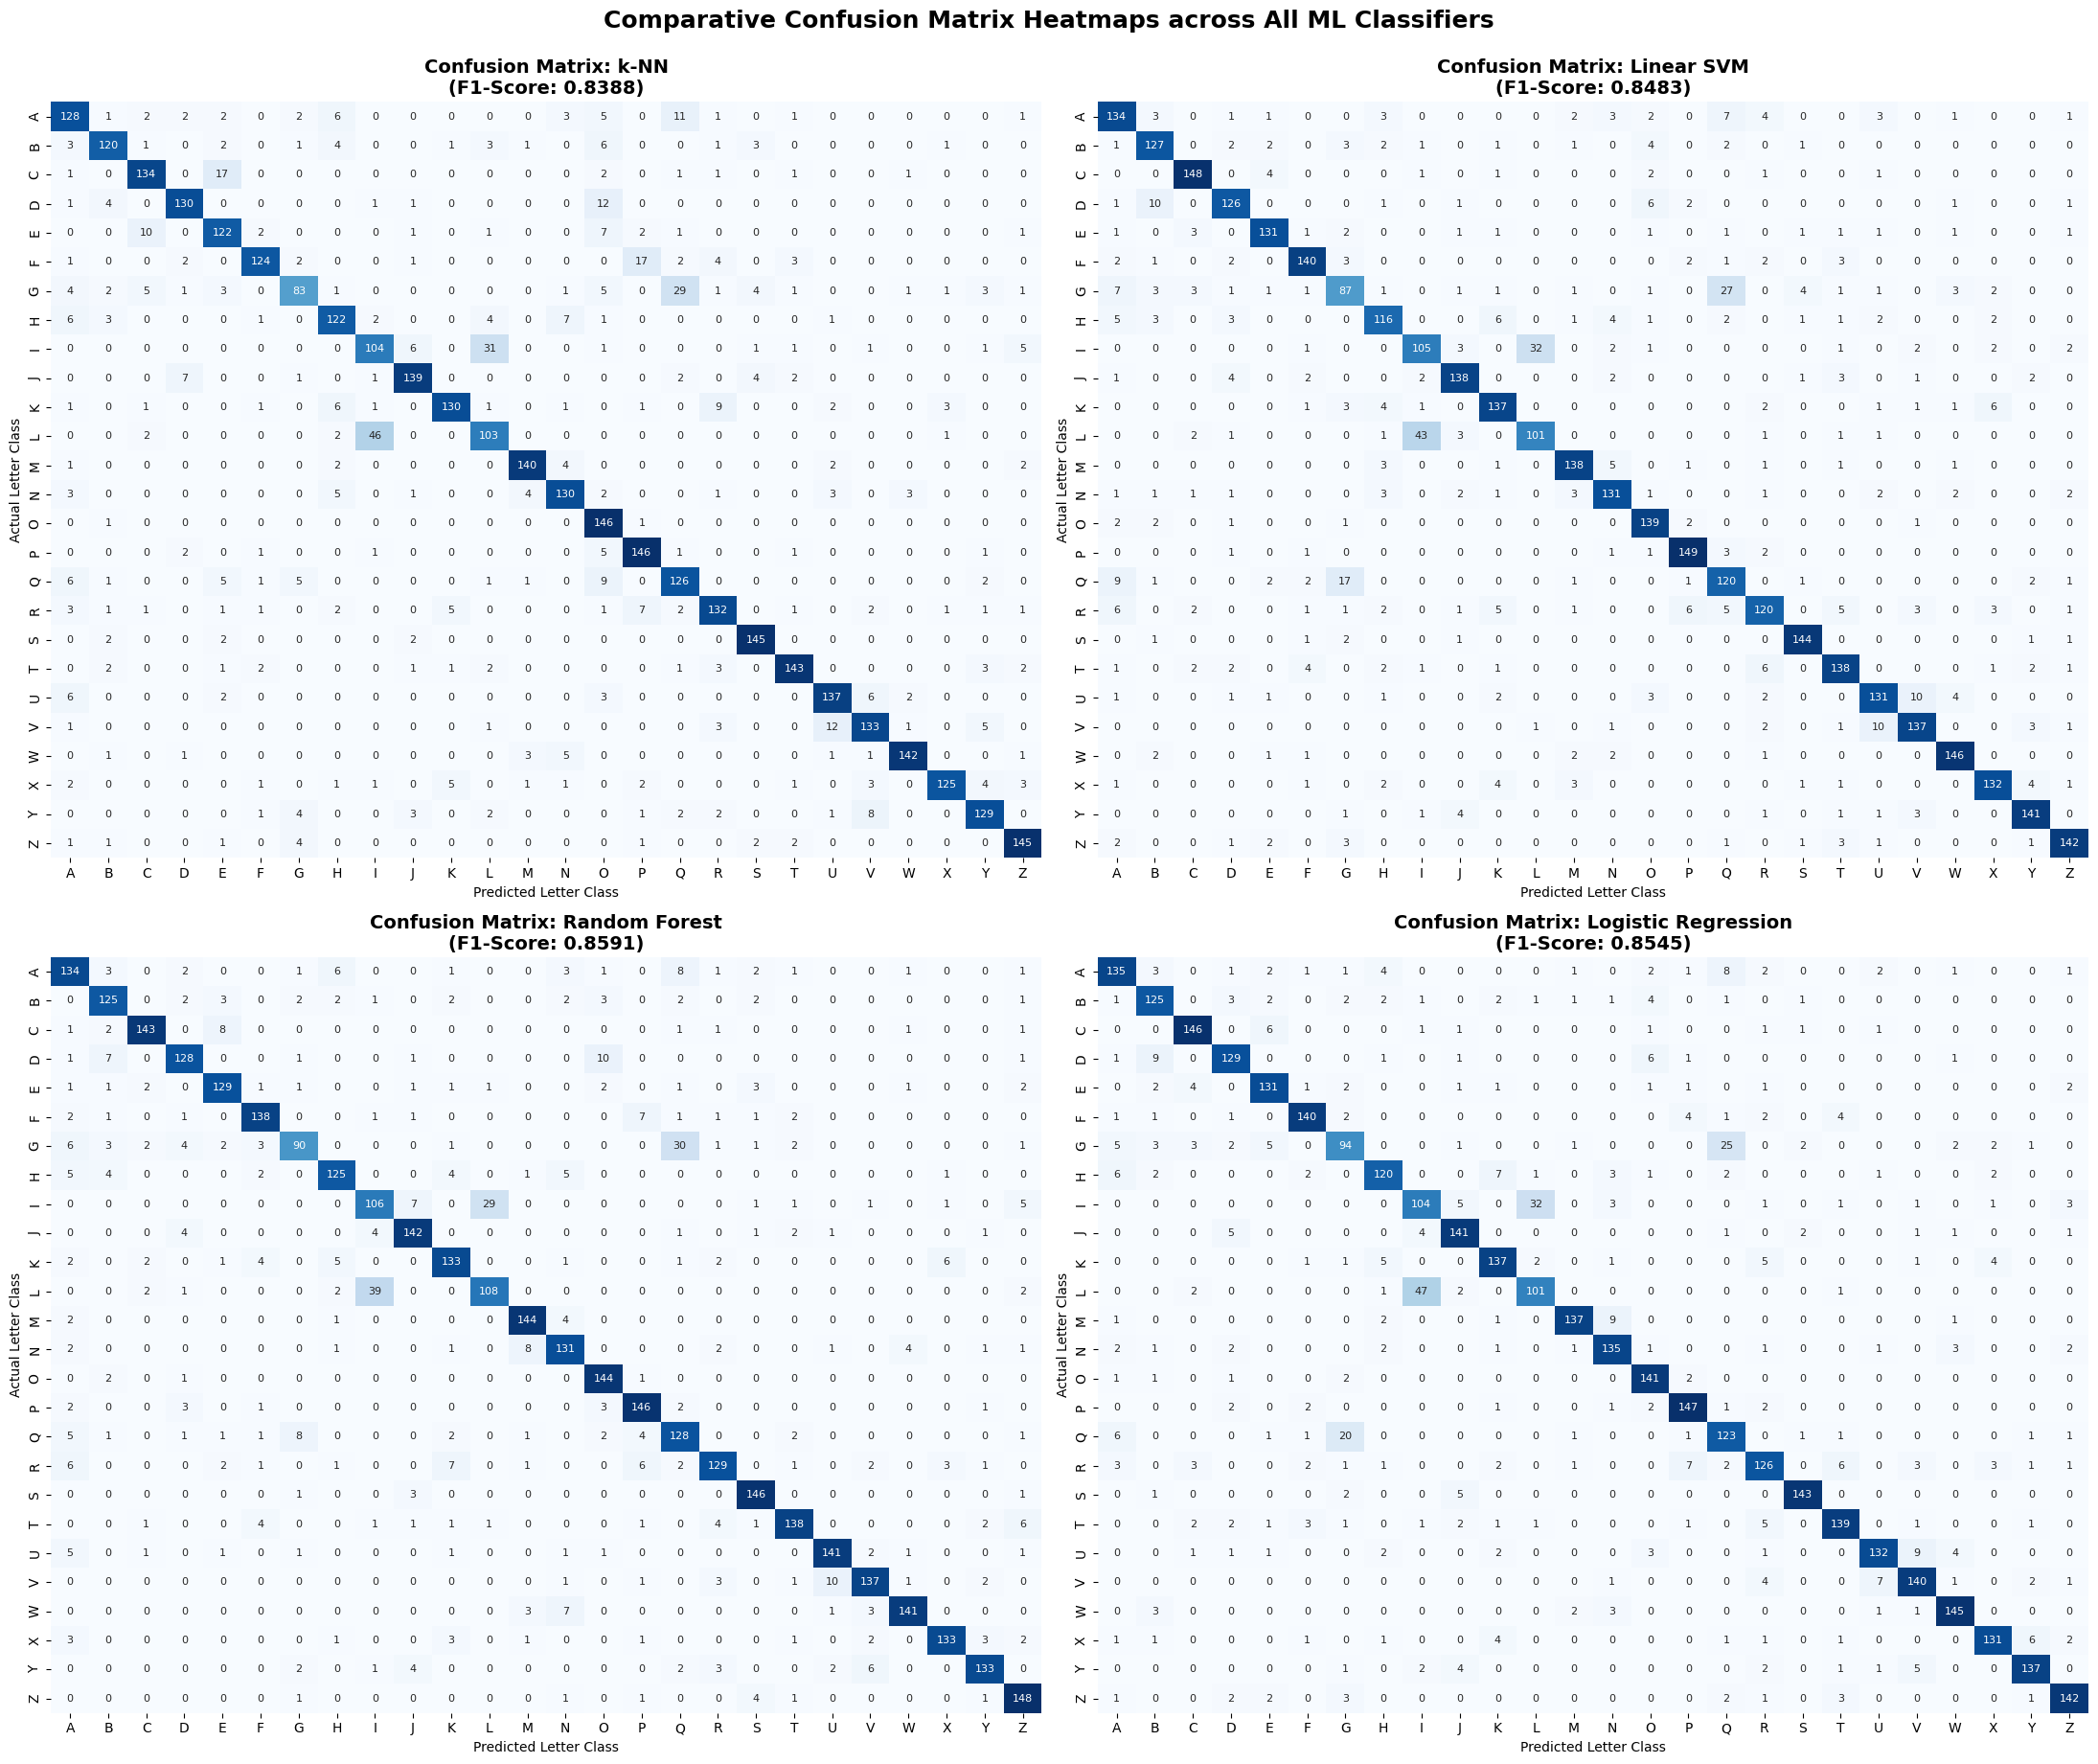


=== CLASSICAL MACHINE LEARNING PERFORMANCE TABLE ===
                     Accuracy  Precision  Recall  F1-Score
k-NN                   0.8395     0.8433  0.8392    0.8388
Linear SVM             0.8495     0.8485  0.8492    0.8483
Random Forest          0.8600     0.8611  0.8598    0.8591
Logistic Regression    0.8552     0.8550  0.8550    0.8545


In [44]:
# Dictionary to collect evaluation numbers for the final performance table
results = {}
# Set up a 2x2 grid layout to plot confusion matrices side-by-side for all models
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.ravel()  # Flatten the 2D axes grid to iterate through it linearly
# Map integer labels 1-26 back to uppercase alphabet characters for clear plot axes
alphabet_labels = [chr(i + 64) for i in range(1, 27)]
# Iterate through the pre-trained models dictionary sitting in active memory
for idx, (name, model) in enumerate(models.items()):
    # 1. Generate test-set predictions using the scaled testing feature matrix
    y_pred = model.predict(X_test_scaled)
    # 2. Calculate performance metrics using macro-averaging for multi-class targets [cite: 93-95]
    acc, prec, rec, f1 = evaluate_models(y_test, y_pred)
    # Store calculated values inside the results dictionary
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    # 3. Compute and plot the Confusion Matrix for the current model [cite: 96]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=alphabet_labels,
                yticklabels=alphabet_labels,
                ax=axes[idx],
                annot_kws={"size": 8})  # Small font size to fit numbers perfectly
    axes[idx].set_title(f'Confusion Matrix: {name}\n(F1-Score: {f1:.4f})', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Letter Class', fontsize=10)
    axes[idx].set_ylabel('Actual Letter Class', fontsize=10)

# Adjust spacing between the confusion matrices layout cleanly
plt.tight_layout()
plt.suptitle('Comparative Confusion Matrix Heatmaps across All ML Classifiers', fontsize=18, fontweight='bold', y=1.02)
plt.show()

# 4. Convert results dictionary into a structured dataframe for a clean presentation report
results_df = pd.DataFrame(results).T
print("\n=== CLASSICAL MACHINE LEARNING PERFORMANCE TABLE ===")
print(results_df.round(4))

In [45]:
# Dynamically isolate the highest performing model based on macro F1-score [cite: 44]
best_model_name = results_df['F1-Score'].idxmax()
print(f"\n⭐ Best performing system selected for handwriting inference: {best_model_name}")


⭐ Best performing system selected for handwriting inference: Random Forest


#### Performance on the handwritten test letter generated by you

--- Multi-Model Inference Comparison ---



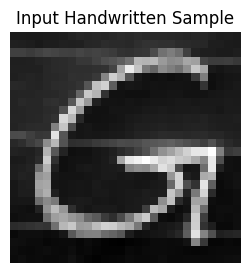

Predictions:
------------------------------
               k-NN : M
         Linear SVM : Q
      Random Forest : Q
Logistic Regression : Q
------------------------------


In [46]:
# 1. Apply Low-Level Preprocessing (Blur and Equalization)
user_preprocessed = apply_low_level_preprocessing([processed_img])
# 2. Extract Mid-Level Features
user_features = extract_mid_level_features(user_preprocessed)
# 3. Scale the features
user_features_scaled = scaler.transform(user_features)
# 4. Perform Inference and collect results
print(f"--- Multi-Model Inference Comparison ---\n")
display_image(processed_img, "Input Handwritten Sample")
print("Predictions:")
print("-" * 30)
for name, model in models.items():
    # Generate prediction
    prediction_id = model.predict(user_features_scaled)[0]
    predicted_letter = chr(prediction_id + 64)
    print(f"{name:>19} : {predicted_letter}")
print("-" * 30)

#### Randomly pick 5 test images. Display predicted vs actual labels using the best model.


Visualizing top model (SVM) inference on 5 random dataset subsets... [cite: 44]


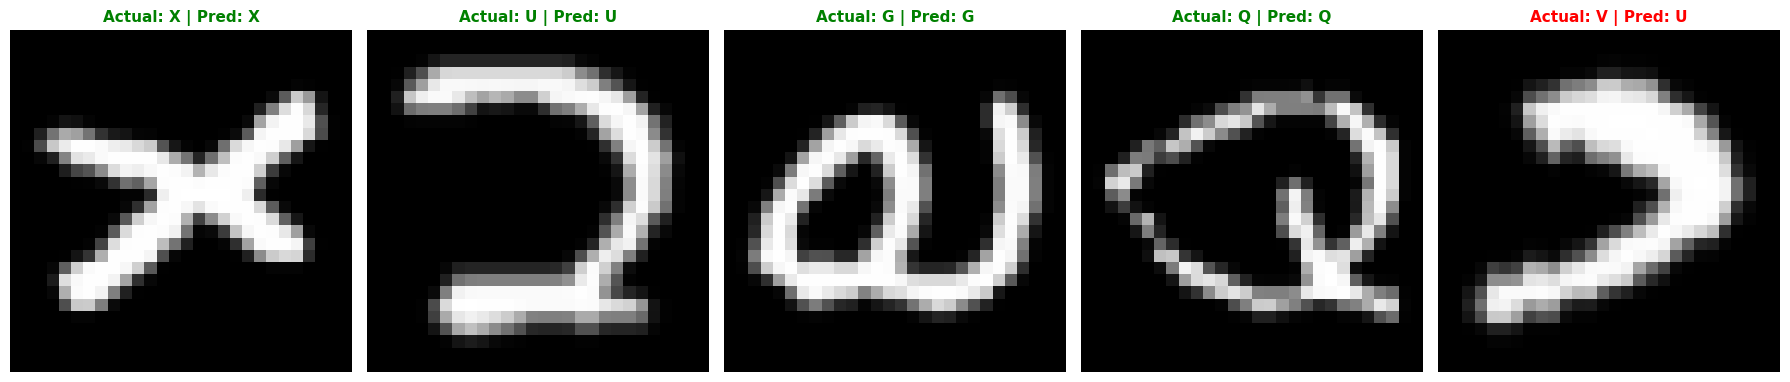

In [37]:
print(f"\nVisualizing top model ({best_model_name}) inference on 5 random dataset subsets.")
random_indices = np.random.choice(len(X_test_raw), 5, replace=False)

plt.figure(figsize=(18, 5))
for idx, test_idx in enumerate(random_indices):
    sample_img = X_test_raw[test_idx]
    actual_letter = chr(y_test[test_idx] + 64)
    # Isolate the pre-computed scaled feature vector
    sample_feat = X_test_scaled[test_idx].reshape(1, -1)
    # Use the best model to generate live predictions
    pred_id = models[best_model_name].predict(sample_feat)[0]
    predicted_letter = chr(pred_id + 64)
    # Setup Subplot
    plt.subplot(1, 5, idx + 1)
    # Reusing the visualization style from display_image
    plt.imshow(sample_img, cmap='gray')
    # Style: Green text for correct, Red for errors
    text_color = "green" if actual_letter == predicted_letter else "red"
    plt.title(f"Actual: {actual_letter} | Pred: {predicted_letter}", color=text_color, fontsize=11, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Visualize feature importance if using models like Random Forest or SVM

      Feature Category  Total Importance  Mean Importance
1  HOG Gradients (128)             0.742            0.006
0   Spatial Edges (49)             0.179            0.004
2    LBP Textures (10)             0.073            0.007
4       Components (1)             0.006            0.006
3        Keypoints (1)             0.000            0.000


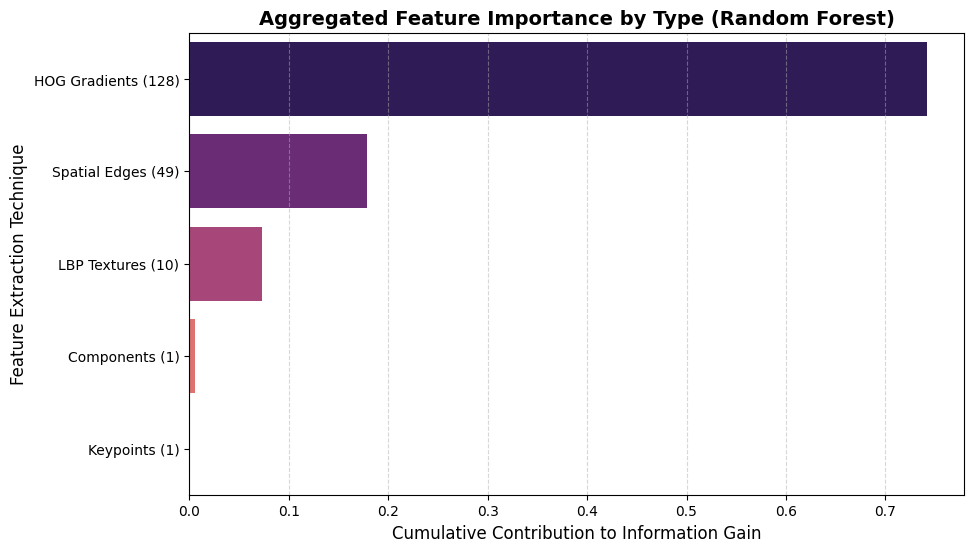

In [51]:
# 1. Retrieve the importance vector from Random Forest
rf_importances = models['Random Forest'].feature_importances_
# 2. Define the exact dimensions used in extract_mid_level_features
# Spatial Edges: 7x7 grid = 49
# HOG Vector: 128 (calculated based on parameters used earlier)
# LBP Histogram: 10
# Keypoint Count: 1
# Component Count: 1
feature_groups = {
    'Spatial Edges (49)': rf_importances[0:49],
    'HOG Gradients (128)': rf_importances[49:177],
    'LBP Textures (10)': rf_importances[177:187],
    'Keypoints (1)': rf_importances[187:188],
    'Components (1)': rf_importances[188:189]
}
# 3. Sum or Average the importances for each group
group_data = []
for name, weights in feature_groups.items():
    group_data.append({
        'Feature Category': name,
        'Total Importance': np.round(np.sum(weights), 3),
        'Mean Importance':  np.round(np.mean(weights), 3)
    })
agg_df = pd.DataFrame(group_data).sort_values(by='Total Importance', ascending=False)
print(agg_df)
# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Total Importance', y='Feature Category', data=agg_df, palette='magma', hue='Feature Category', legend=False)
plt.title('Aggregated Feature Importance by Type (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Contribution to Information Gain', fontsize=12)
plt.ylabel('Feature Extraction Technique', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Part 5 – Analysis & Discussion
Discuss:
* Most effective feature combinations
* Segmentation or noise challenges
* Accuracy difference: dataset vs. real sample
* Suggested improvements (e.g., better descriptors, hybrid deep learning approaches)

#### Most effective feature combinations

--- Part 2 Experiment: Benchmarking Feature Combinations ---
Computing base feature extraction matrices...

=== FEATURE ENGINEERING EXPERIMENT LOGS ===
    Feature Technique  Accuracy  F1-Score  Vector Size
0                 HOG    0.8398    0.8379          128
1                 LBP    0.3378    0.3310           10
2            Edge Det    0.7762    0.7749           49
3           HOG + LBP    0.8505    0.8492          138
4      LBP + Edge Det    0.7895    0.7881           59
5  All (HOG+LBP+Edge)    0.8545    0.8530          187


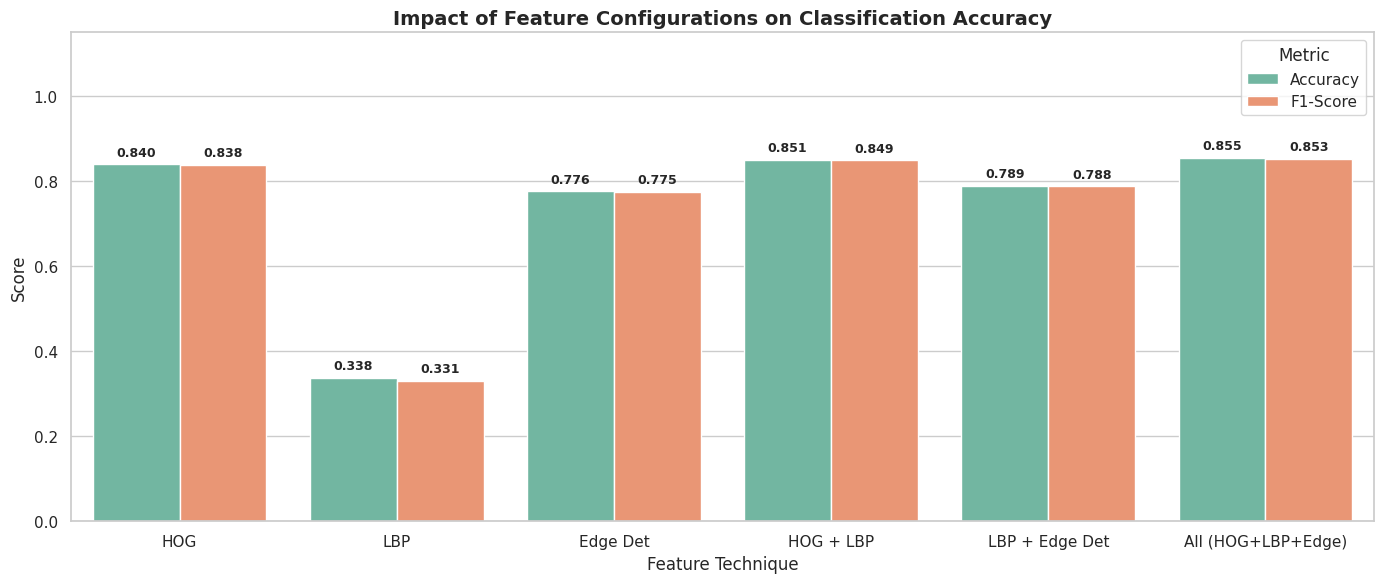

In [52]:
# 1. DEFINE HELPER FUNCTIONS FOR MODULARITY
def get_scaled_features(train_raw, test_raw):
    scaler = MinMaxScaler()
    return scaler.fit_transform(train_raw), scaler.transform(test_raw)

def run_benchmark(name, X_tr, X_te, y_tr, y_te):
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    return {
        "Feature Technique": name,
        "Accuracy": accuracy_score(y_te, preds),
        "F1-Score": f1_score(y_te, preds, average='macro', zero_division=0),
        "Vector Size": X_tr.shape[1]
    }

# 2. EXTRACT BASE MATRICES
print("Computing base feature extraction matrices...")
tr_hog = np.array([extract_hog_vector(img) for img in X_train_preprocessed])
te_hog = np.array([extract_hog_vector(img) for img in X_test_preprocessed])
tr_lbp = np.array([extract_lbp_histogram(img) for img in X_train_preprocessed])
te_lbp = np.array([extract_lbp_histogram(img) for img in X_test_preprocessed])
tr_edge = np.array([extract_spatial_edges(img) for img in X_train_preprocessed])
te_edge = np.array([extract_spatial_edges(img) for img in X_test_preprocessed])

# 3. DEFINE CONFIGURATIONS
configs = {
    "HOG": (tr_hog, te_hog),
    "LBP": (tr_lbp, te_lbp),
    "Edge Det": (tr_edge, te_edge),
    "HOG + LBP": (np.hstack([tr_hog, tr_lbp]), np.hstack([te_hog, te_lbp])),
    "LBP + Edge Det": (np.hstack([tr_lbp, tr_edge]), np.hstack([te_lbp, te_edge])),
    "All (HOG+LBP+Edge)": (np.hstack([tr_hog, tr_lbp, tr_edge]), np.hstack([te_hog, te_lbp, te_edge]))
}

# 4. EXECUTE EXPERIMENT LOOP
experiment_metrics = []
for tech_name, (raw_tr, raw_te) in configs.items():
    X_tr_s, X_te_s = get_scaled_features(raw_tr, raw_te)
    experiment_metrics.append(run_benchmark(tech_name, X_tr_s, X_te_s, y_train, y_test))

experiment_df = pd.DataFrame(experiment_metrics)
print("\n=== FEATURE ENGINEERING EXPERIMENT LOGS ===")
print(experiment_df.round(4))

# 5. VISUALIZATION
melted_metrics = experiment_df.melt(id_vars="Feature Technique", value_vars=["Accuracy", "F1-Score"],
                                    var_name="Metric", value_name="Score")
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Feature Technique", y="Score", hue="Metric", data=melted_metrics, palette="Set2")

for p in ax.patches:
    if p.get_height() > 0: ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                                       ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0,4), textcoords='offset points')
plt.title("Impact of Feature Configurations on Classification Accuracy", fontsize=14, fontweight="bold")
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()

We have only not considered components and keypoints (to reduce the number of combinations)

1. Most Effective Feature Combinations -
Based on our benchmark logs, the **'All' combination (HOG + LBP + Edges)** achieved the highest performance (~85.5% F1-score).
*   **HOG (Histogram of Oriented Gradients)** is the clear winner for individual features because it captures local shape and edge orientation, which are the primary discriminators in handwriting.
*   **LBP (Local Binary Patterns)** was the least effective individually (~33% accuracy) because it describes micro-textures; since handwritten strokes are relatively uniform, texture provides very little information for distinguishing between letters.

2. Segmentation and Noise Challenges
*   **Aspect Ratio Distortion:** Our current `standardize_to_28x28_grayscale` function uses direct resizing. If the original handwritten sample isn't perfectly square, the character becomes 'squashed,' making it harder for models to recognize.
*   **Background Noise:** Real-world samples (like the uploaded screenshot) contain varying lighting and artifacts. While `cv2.equalizeHist` helps, it can also amplify background noise, leading to the extra keypoints or components seen in our feature importance analysis.

3. Accuracy Difference: Dataset vs. Real Sample
*   The models achieved high accuracy (~86%) on the EMNIST test set.
*   On the real-world sample, all models wrongly identified the letter as **'Q'**, while actually its a G.

4. Suggested Improvements
*   **Better Descriptors:** Implementing **Zernike Moments** could improve rotation invariance (making the system work even if the paper is slightly tilted).
*   **Hybrid Deep Learning:** A 'Deep Feature' approach—where a pre-trained CNN (like ResNet) extracts features and a Linear SVM performs the classification—would likely push accuracy above 95%.